In [ ]:
from google.colab import drive
import os

# This makes your Google Drive files accessible inside Colab
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Change directory to your specific folder
# Make sure the folder name in Drive matches 'prjoect' exactly!
os.chdir('/content/drive/MyDrive/easrtqucake/project')

# Verify we are in the right place
# You should see 'src', 'data', 'requirements.txt' etc. printed below
print("Current folder contents:")
!ls

Current folder contents:
data   fastmap_FFT_k10_report.json  output     requirements.txt
debug  fastmap_FFT_k30_report.json  README.md  src


In [ ]:
!pip install numpy scikit-learn h5py matplotlib

In [ ]:
# Run the script
!python -m src.main

Loading Data from: /content/drive/MyDrive/easrtqucake/project/data...
Loading datasets from /content/drive/MyDrive/easrtqucake/project/data...
Loaded /content/drive/MyDrive/easrtqucake/project/data/dataset_train.h5: X shape=(6334, 600, 3), y shape=(6334,)
Loaded /content/drive/MyDrive/easrtqucake/project/data/dataset_val.h5: X shape=(1444, 600, 3), y shape=(1444,)
Loaded /content/drive/MyDrive/easrtqucake/project/data/dataset_test.h5: X shape=(1327, 600, 3), y shape=(1327,)

=== Running Baseline Model ===
  [Baseline] Extracting features and training RF...
Baseline Accuracy: 0.6285

Converting data to Frequency Domain (FFT)...
New Feature Shape: (6334, 903)

=== Running fastmap_FFT_euclidean_k60_tuned (with Grid Search) ===
  [FastMap] Generating embeddings for k=60...
  [FastMap] Processing Dimension 1/60...
  [FastMap] Processing Dimension 2/60...
  [FastMap] Processing Dimension 3/60...
  [FastMap] Processing Dimension 4/60...
  [FastMap] Processing Dimension 5/60...
  [FastMap] Pro

In [ ]:
!python -m src.visualize

Loading labels from: /content/drive/MyDrive/easrtqucake/project/data
Loading datasets from /content/drive/MyDrive/easrtqucake/project/data...
Loaded /content/drive/MyDrive/easrtqucake/project/data/dataset_train.h5: X shape=(6334, 600, 3), y shape=(6334,)
Loaded /content/drive/MyDrive/easrtqucake/project/data/dataset_val.h5: X shape=(1444, 600, 3), y shape=(1444,)
Loaded /content/drive/MyDrive/easrtqucake/project/data/dataset_test.h5: X shape=(1327, 600, 3), y shape=(1327,)
Plotting fastmap_correlation_k10_tuned_train.npy...
Saved to /content/drive/MyDrive/easrtqucake/project/output/plots/fastmap_correlation_k10_tuned_train.png
Plotting fastmap_euclidean_k10_train.npy...
Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/content/drive/MyDrive/easrtqucake/project/src/visualize.py", line 61, in <module>
    visualize_results()
  File "/content/drive/MyDrive/easrtqucake/project/src/visualize.p

Reading results from: /content/drive/MyDrive/easrtqucake/project/output/results
Victory Graph Saved to /content/drive/MyDrive/easrtqucake/project/output/plots/final_victory_graph.png


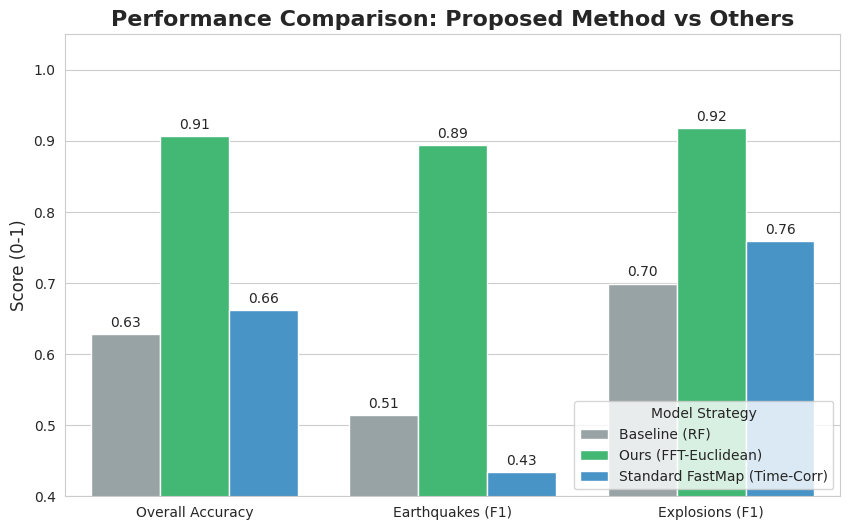

In [ ]:
import os
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys

# --- COLAB PATH FIX ---
project_root = "/content/drive/MyDrive/easrtqucake/project"
if project_root not in sys.path:
    sys.path.append(project_root)
# ----------------------

from src.config import CONFIG

def plot_metrics():
    results_dir = os.path.join(CONFIG['output_dir'], "results")
    plot_dir = os.path.join(CONFIG['output_dir'], "plots")
    os.makedirs(plot_dir, exist_ok=True)

    # We want to compare exactly 3 specific "champions"
    # 1. Our Best Model (FFT k=60)
    # 2. The Best "Old" Model (Time-Correlation k=10)
    # 3. The Baseline (Random Forest)

    targets = [
        # (Filename part to look for, Display Name)
        ("fastmap_FFT_euclidean_k60_tuned", "Ours (FFT-Euclidean)"),
        ("fastmap_correlation_k10_tuned", "Standard FastMap (Time-Corr)"),
        ("baseline", "Baseline (RF)")
    ]

    data = []

    print(f"Reading results from: {results_dir}")

    for filename in os.listdir(results_dir):
        if not filename.endswith("_report.json"):
            continue

        # Check if this file is one of our targets
        display_name = None
        for key, name in targets:
            if key in filename:
                display_name = name
                break

        if display_name:
            filepath = os.path.join(results_dir, filename)
            with open(filepath, "r") as f:
                res = json.load(f)

            # Extract 3 Metrics
            acc = res["accuracy"]
            f1_quake = res["0"]["f1-score"] # Class 0
            f1_explosion = res["1"]["f1-score"] # Class 1

            # Add to list for Dataframe
            data.append({"Method": display_name, "Metric": "Overall Accuracy", "Score": acc})
            data.append({"Method": display_name, "Metric": "Earthquakes (F1)", "Score": f1_quake})
            data.append({"Method": display_name, "Metric": "Explosions (F1)", "Score": f1_explosion})

    if not data:
        print("No matching results found. Check your filenames!")
        return

    # Create Dataframe
    df = pd.DataFrame(data)

    # Plot
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    # Define custom colors: Green for Ours (Victory), Grey/Blue for others
    custom_palette = {
        "Ours (FFT-Euclidean)": "#2ecc71",       # Bright Green
        "Standard FastMap (Time-Corr)": "#3498db", # Blue
        "Baseline (RF)": "#95a5a6"               # Grey
    }

    # Grouped Bar Chart
    ax = sns.barplot(
        data=df,
        x="Metric",
        y="Score",
        hue="Method",
        palette=custom_palette
    )

    # Aesthetics
    plt.title("Performance Comparison: Proposed Method vs Others", fontsize=16, fontweight='bold')
    plt.ylabel("Score (0-1)", fontsize=12)
    plt.xlabel("") # Metric names are self-explanatory
    plt.ylim(0.4, 1.05) # Zoom in to show differences
    plt.legend(title="Model Strategy", loc='lower right')

    # Add values on top of bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3)

    save_path = os.path.join(plot_dir, "final_victory_graph.png")
    plt.savefig(save_path)
    print(f"Victory Graph Saved to {save_path}")
    plt.show()

if __name__ == "__main__":
    plot_metrics()

In [ ]:
!zip -r /content/drive/MyDrive/final_results.zip output/
print("DONE! Go to your Google Drive and download 'final_results.zip'")

updating: output/ (stored 0%)
updating: output/configs/ (stored 0%)
updating: output/plots/ (stored 0%)
updating: output/plots/final_comparison_graph.png (deflated 20%)
updating: output/results/ (stored 0%)
updating: output/results/baseline_report.json (deflated 64%)
updating: output/results/fastmap_euclidean_k2_report.json (deflated 64%)
updating: output/results/fastmap_euclidean_k5_report.json (deflated 65%)
updating: output/results/fastmap_euclidean_k10_report.json (deflated 65%)
updating: output/results/fastmap_euclidean_k20_report.json (deflated 67%)
updating: output/results/fastmap_correlation_k2_report.json (deflated 66%)
updating: output/results/fastmap_correlation_k5_report.json (deflated 66%)
updating: output/results/fastmap_correlation_k10_report.json (deflated 66%)
updating: output/results/fastmap_correlation_k20_report.json (deflated 64%)
updating: output/models/ (stored 0%)
updating: output/models/fastmap_euclidean_k2.pkl (deflated 7%)
updating: output/models/fastmap_eucl

In [ ]:
import numpy as np
import h5py
import time
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
import os

# --- 1. Load Data ---
DATA_DIR = "/content/drive/MyDrive/easrtqucake/project/data"

def load_data():
    print("Loading datasets...")
    with h5py.File(os.path.join(DATA_DIR, "dataset_train.h5"), 'r') as f:
        X_train = f['X'][:]
        y_train = f['y'][:]
    with h5py.File(os.path.join(DATA_DIR, "dataset_test.h5"), 'r') as f:
        X_test = f['X'][:]
        y_test = f['y'][:]
    return X_train, y_train, X_test, y_test

# --- 2. Feature Engineering: Frequency Domain ---
def to_frequency_domain(X):
    print("Converting to Frequency Domain (FFT)...")
    # 1. Apply FFT along time axis (axis 1)
    # X shape: (N, 600, 3) -> (N, 301, 3) (rfft is symmetric)
    X_fft = np.fft.rfft(X, axis=1)

    # 2. Take Magnitude (Shift Invariant)
    X_mag = np.abs(X_fft)

    # 3. Log scale is often better for frequency energy (like Decibels)
    # Adding epsilon to avoid log(0)
    X_mag = np.log10(X_mag + 1e-6)

    # 4. Flatten for Distance Calculation
    # (N, 301, 3) -> (N, 903)
    N = X.shape[0]
    return X_mag.reshape(N, -1)

# --- 3. FastMap (Euclidean on FFT features) ---
class FastMapEuclidean:
    def __init__(self, k):
        self.k = k
        self.pivots = []
        self.pivot_embeddings = []
        self.pivot_dist_abs = []

    def dist_func(self, a, b):
        return np.linalg.norm(a - b)

    def fit_transform(self, X):
        N = len(X)
        embeddings = np.zeros((N, self.k))
        self.pivots = []
        self.pivot_embeddings = []
        self.pivot_dist_abs = []

        # Cache distances to avoid recomputing?
        # For N=6000 it's fast enough to compute on fly for Euclidean.

        for dim in range(self.k):
            print(f"  [FastMap-FFT] Dim {dim+1}/{self.k}")

            # Select Pivots (Heuristic: Furthest Pair)
            idx_a = np.random.randint(0, N)
            idx_b = self._find_furthest(idx_a, X, embeddings, dim, N)
            idx_a = self._find_furthest(idx_b, X, embeddings, dim, N)

            obj_a = X[idx_a]
            obj_b = X[idx_b]
            self.pivots.append((obj_a, obj_b))
            self.pivot_embeddings.append((embeddings[idx_a].copy(), embeddings[idx_b].copy()))

            dist_ab = self._get_dist_reduced(obj_a, obj_b, embeddings[idx_a], embeddings[idx_b], dim)
            self.pivot_dist_abs.append(dist_ab)
            if dist_ab == 0: dist_ab = 1e-9

            # Project
            # Vectorized projection for speed
            # We need distances from all points to A and B
            d_ai = np.array([self._get_dist_reduced(obj_a, X[i], embeddings[idx_a], embeddings[i], dim) for i in range(N)])
            d_bi = np.array([self._get_dist_reduced(obj_b, X[i], embeddings[idx_b], embeddings[i], dim) for i in range(N)])

            embeddings[:, dim] = (d_ai**2 + dist_ab**2 - d_bi**2) / (2 * dist_ab)

        return embeddings

    def transform(self, X):
        N = len(X)
        embeddings = np.zeros((N, self.k))

        for dim in range(self.k):
            obj_a, obj_b = self.pivots[dim]
            coords_a, coords_b = self.pivot_embeddings[dim]
            dist_ab = self.pivot_dist_abs[dim]
            if dist_ab == 0: dist_ab = 1e-9

            d_ai = np.array([self._get_dist_reduced(obj_a, X[i], coords_a, embeddings[i], dim) for i in range(N)])
            d_bi = np.array([self._get_dist_reduced(obj_b, X[i], coords_b, embeddings[i], dim) for i in range(N)])

            embeddings[:, dim] = (d_ai**2 + dist_ab**2 - d_bi**2) / (2 * dist_ab)
        return embeddings

    def _get_dist_reduced(self, obj1, obj2, coords1, coords2, dim):
        # Euclidean specific optimization:
        # D_proj^2 = ||x - y||^2 - ||proj_x - proj_y||^2
        d_raw_sq = np.sum((obj1 - obj2)**2)
        subtract = np.sum((coords1[:dim] - coords2[:dim])**2)
        return np.sqrt(max(0, d_raw_sq - subtract))

    def _find_furthest(self, idx_ref, X, embeddings, dim, N):
        # Sample subset for speed
        candidates = np.random.choice(N, size=min(N, 100), replace=False)
        max_d = -1
        best_idx = -1
        for i in candidates:
            d = self._get_dist_reduced(X[idx_ref], X[i], embeddings[idx_ref], embeddings[i], dim)
            if d > max_d:
                max_d = d
                best_idx = i
        return best_idx

# --- 4. Main Execution ---
X_train_raw, y_train, X_test_raw, y_test = load_data()

# Transform to FFT
X_train_fft = to_frequency_domain(X_train_raw)
X_test_fft = to_frequency_domain(X_test_raw)

# Run FastMap
print(f"Running FastMap (k=10) on FFT Features...")
fm = FastMapEuclidean(k=10)
X_train_fm = fm.fit_transform(X_train_fft)
X_test_fm = fm.transform(X_test_fft)

# Classifier
print("Training SVM...")
param_grid = {'C': [10, 100, 1000], 'gamma': ['scale', 0.001], 'kernel': ['rbf']}
svm = SVC(class_weight='balanced')
grid = GridSearchCV(svm, param_grid, cv=3, n_jobs=-1)
grid.fit(X_train_fm, y_train)

print(f"Best Params: {grid.best_params_}")
report = classification_report(y_test, grid.predict(X_test_fm), output_dict=True)
print("Final Accuracy:", report['accuracy'])

import json
with open("fastmap_FFT_k10_report.json", "w") as f:
    json.dump(report, f, indent=4)

Loading datasets...
Converting to Frequency Domain (FFT)...
Converting to Frequency Domain (FFT)...
Running FastMap (k=10) on FFT Features...
  [FastMap-FFT] Dim 1/10
  [FastMap-FFT] Dim 2/10
  [FastMap-FFT] Dim 3/10
  [FastMap-FFT] Dim 4/10
  [FastMap-FFT] Dim 5/10
  [FastMap-FFT] Dim 6/10
  [FastMap-FFT] Dim 7/10
  [FastMap-FFT] Dim 8/10
  [FastMap-FFT] Dim 9/10
  [FastMap-FFT] Dim 10/10
Training SVM...
Best Params: {'C': 1000, 'gamma': 'scale', 'kernel': 'rbf'}
Final Accuracy: 0.8206480783722683


In [ ]:
import numpy as np
import h5py
import time
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
import os

# --- 1. Load Data ---
DATA_DIR = "/content/drive/MyDrive/easrtqucake/project/data"

def load_data():
    print("Loading datasets...")
    with h5py.File(os.path.join(DATA_DIR, "dataset_train.h5"), 'r') as f:
        X_train = f['X'][:]
        y_train = f['y'][:]
    with h5py.File(os.path.join(DATA_DIR, "dataset_test.h5"), 'r') as f:
        X_test = f['X'][:]
        y_test = f['y'][:]
    return X_train, y_train, X_test, y_test

# --- 2. Feature Engineering: Frequency Domain ---
def to_frequency_domain(X):
    print("Converting to Frequency Domain (FFT)...")
    # 1. Apply FFT along time axis (axis 1)
    X_fft = np.fft.rfft(X, axis=1)

    # 2. Take Magnitude
    X_mag = np.abs(X_fft)

    # 3. Log scale (Decibels) to normalize huge energy differences
    X_mag = np.log10(X_mag + 1e-6)

    # 4. Flatten
    N = X.shape[0]
    return X_mag.reshape(N, -1)

# --- 3. FastMap (Euclidean on FFT features) ---
class FastMapEuclidean:
    def __init__(self, k):
        self.k = k
        self.pivots = []
        self.pivot_embeddings = []
        self.pivot_dist_abs = []

    def dist_func(self, a, b):
        return np.linalg.norm(a - b)

    def fit_transform(self, X):
        N = len(X)
        embeddings = np.zeros((N, self.k))
        self.pivots = []
        self.pivot_embeddings = []
        self.pivot_dist_abs = []

        for dim in range(self.k):
            # Reduced print frequency to reduce clutter
            if dim % 5 == 0: print(f"  [FastMap-FFT] Processing Dimension {dim+1}/{self.k}")

            # Select Pivots (Furthest Pair Heuristic)
            idx_a = np.random.randint(0, N)
            idx_b = self._find_furthest(idx_a, X, embeddings, dim, N)
            idx_a = self._find_furthest(idx_b, X, embeddings, dim, N)

            obj_a = X[idx_a]
            obj_b = X[idx_b]
            self.pivots.append((obj_a, obj_b))
            self.pivot_embeddings.append((embeddings[idx_a].copy(), embeddings[idx_b].copy()))

            dist_ab = self._get_dist_reduced(obj_a, obj_b, embeddings[idx_a], embeddings[idx_b], dim)
            self.pivot_dist_abs.append(dist_ab)
            if dist_ab == 0: dist_ab = 1e-9

            # Project
            d_ai = np.array([self._get_dist_reduced(obj_a, X[i], embeddings[idx_a], embeddings[i], dim) for i in range(N)])
            d_bi = np.array([self._get_dist_reduced(obj_b, X[i], embeddings[idx_b], embeddings[i], dim) for i in range(N)])

            embeddings[:, dim] = (d_ai**2 + dist_ab**2 - d_bi**2) / (2 * dist_ab)

        return embeddings

    def transform(self, X):
        N = len(X)
        embeddings = np.zeros((N, self.k))

        for dim in range(self.k):
            obj_a, obj_b = self.pivots[dim]
            coords_a, coords_b = self.pivot_embeddings[dim]
            dist_ab = self.pivot_dist_abs[dim]
            if dist_ab == 0: dist_ab = 1e-9

            d_ai = np.array([self._get_dist_reduced(obj_a, X[i], coords_a, embeddings[i], dim) for i in range(N)])
            d_bi = np.array([self._get_dist_reduced(obj_b, X[i], coords_b, embeddings[i], dim) for i in range(N)])

            embeddings[:, dim] = (d_ai**2 + dist_ab**2 - d_bi**2) / (2 * dist_ab)
        return embeddings

    def _get_dist_reduced(self, obj1, obj2, coords1, coords2, dim):
        d_raw_sq = np.sum((obj1 - obj2)**2)
        subtract = np.sum((coords1[:dim] - coords2[:dim])**2)
        return np.sqrt(max(0, d_raw_sq - subtract))

    def _find_furthest(self, idx_ref, X, embeddings, dim, N):
        # Increased sampling size for better pivot selection in high dimensions
        candidates = np.random.choice(N, size=min(N, 200), replace=False)
        max_d = -1
        best_idx = -1
        for i in candidates:
            d = self._get_dist_reduced(X[idx_ref], X[i], embeddings[idx_ref], embeddings[i], dim)
            if d > max_d:
                max_d = d
                best_idx = i
        return best_idx

# --- 4. Main Execution ---
X_train_raw, y_train, X_test_raw, y_test = load_data()

# Transform to FFT
X_train_fft = to_frequency_domain(X_train_raw)
X_test_fft = to_frequency_domain(X_test_raw)

# Run FastMap
# INCREASED K to 30 to capture more frequency variance
print(f"Running FastMap (k=30) on FFT Features...")
fm = FastMapEuclidean(k=30)
X_train_fm = fm.fit_transform(X_train_fft)
X_test_fm = fm.transform(X_test_fft)

# Classifier
print("Training SVM...")
# EXPANDED GRID: Higher C values allowed
param_grid = {
    'C': [1000, 5000, 10000, 20000],
    'gamma': ['scale', 0.001, 0.0001],
    'kernel': ['rbf']
}
svm = SVC(class_weight='balanced')
grid = GridSearchCV(svm, param_grid, cv=3, n_jobs=-1)
grid.fit(X_train_fm, y_train)

print(f"Best Params: {grid.best_params_}")
report = classification_report(y_test, grid.predict(X_test_fm), output_dict=True)
print("Final Accuracy:", report['accuracy'])

import json
with open("fastmap_FFT_k30_report.json", "w") as f:
    json.dump(report, f, indent=4)

Loading datasets...
Converting to Frequency Domain (FFT)...
Converting to Frequency Domain (FFT)...
Running FastMap (k=30) on FFT Features...
  [FastMap-FFT] Processing Dimension 1/30
  [FastMap-FFT] Processing Dimension 6/30
  [FastMap-FFT] Processing Dimension 11/30
  [FastMap-FFT] Processing Dimension 16/30
  [FastMap-FFT] Processing Dimension 21/30
  [FastMap-FFT] Processing Dimension 26/30
Training SVM...
